# SmartScan CSCI435
## version 1
### 4-Class Document Classifier



---


uses two datasets to cover 4 categories.

trains a MobileNetV2 classifier on 4 document types

I added as much comments as i could in between the code so that everything is clear and easy to read:)



---



**classes:**

Handwritten
* source: senju14 `document/` folder
* all handwritten documents

invoices
* source: senju14 `invoice/` folder
* reciepts and invoices

form
* source: senju14 `form/` folder
* structured form documents

printed page
* source: suvroo `Report/` folder
* machine-printed documents



---



**Outputs:**
* `document_classifier_v2.pt` : trained model weights
* `classification_core.py` : drop-in inference module for the Streamlit app


Senju14 dataset :

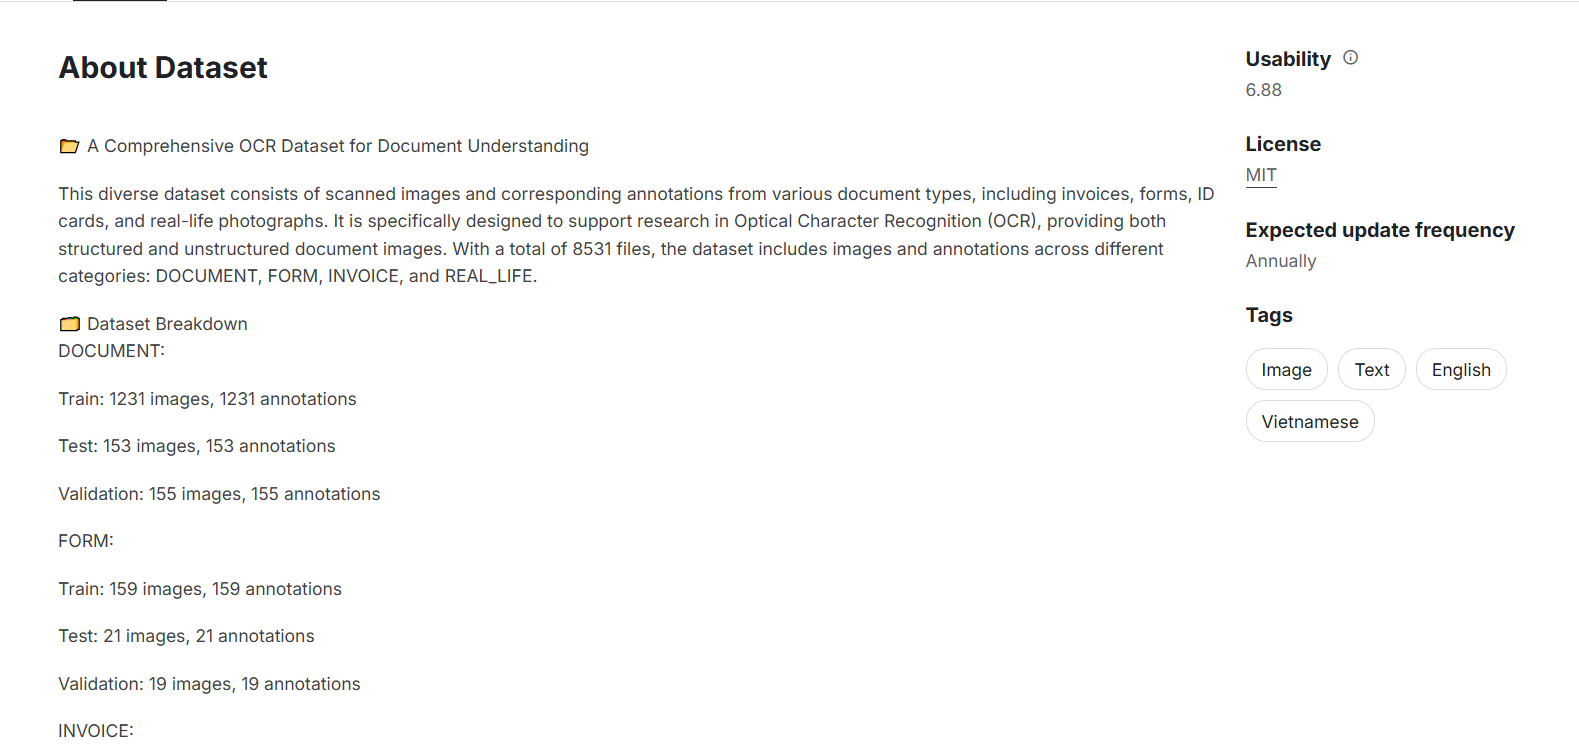



suvroo datase:

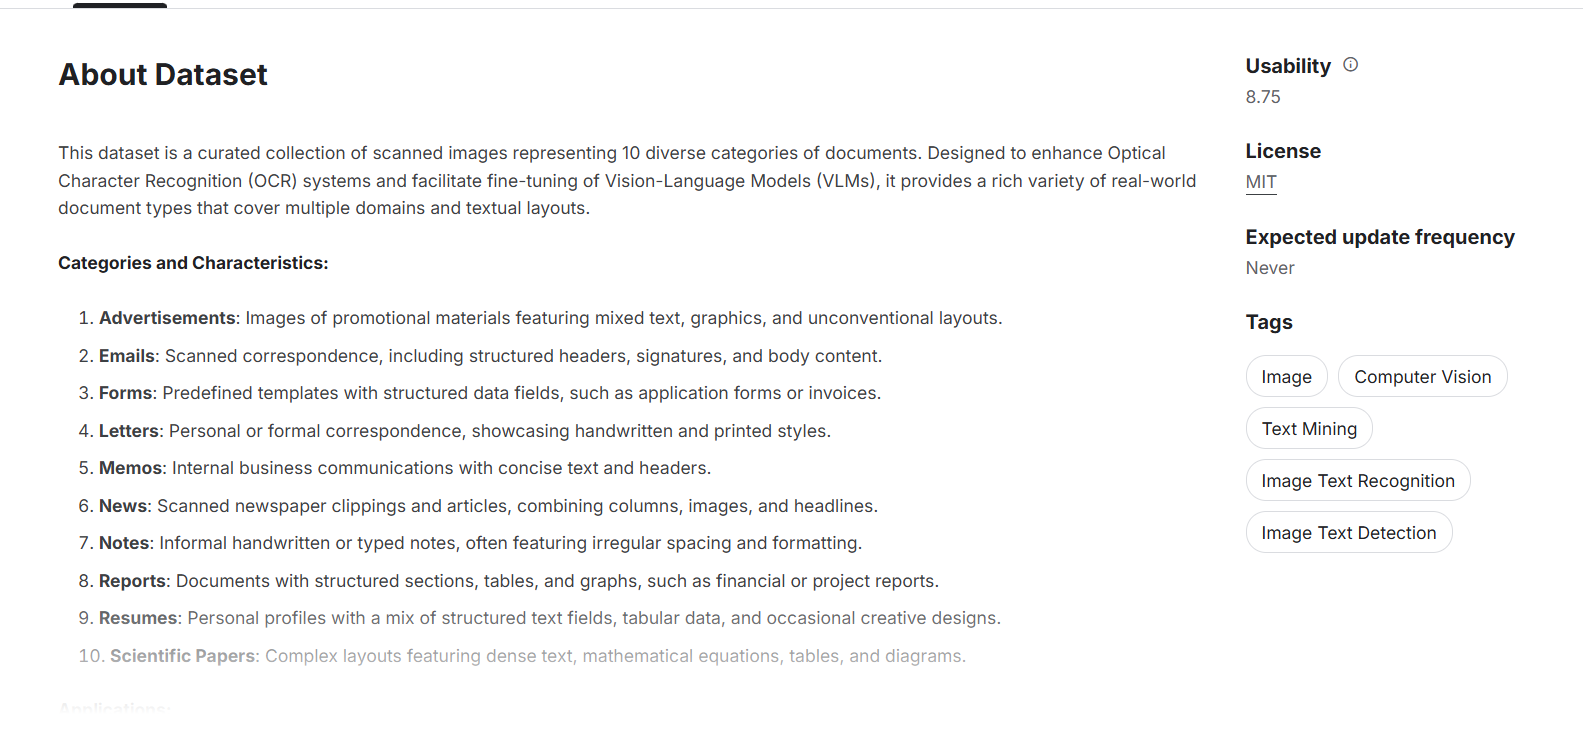

### Table of Contents

1.  [Imports](#1.-Imports)
2.  [Download Datasets](#2.-Download-Datasets)
3.  [Explore Structure](#3.-Explore-Structure)
4.  [Config & Utilities](#4.-Config-&-Utilities)
5.  [Build Dataset](#5.-Build-Dataset)
6.  [Model Setup](#6.-Model-Setup)
7.  [Training](#7.-Training)
8.  [Evaluation](#8.-Evaluation)
9.  [Visualize Samples](#9.-Visualize-Samples)
10. [Save to Drive](#10.-Save-to-Drive)
11. [Write classification_core.py](#11.-Write-classification_core.py)

## 1. Imports

In [ ]:
import os, random, time, shutil
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from PIL import Image
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from sklearn.metrics import classification_report


## 2. Download Datasets

In [ ]:
import kagglehub

#senju14: has premade train val test splits
path_senju = kagglehub.dataset_download("senju14/ocr-dataset-of-multi-type-documents")
print("senju14:", path_senju)

#suvroo: report folder is used for printed_page class since we didnt have that in senju14
path_suvroo = kagglehub.dataset_download("suvroo/scanned-images-dataset-for-ocr-and-vlm-finetuning")
print("suvroo: ", path_suvroo)


100%|██████████| 5.16G/5.16G [03:19<00:00, 27.8MB/s]

Extracting files...


senju14: /root/.cache/kagglehub/datasets/senju14/ocr-dataset-of-multi-type-documents/versions/3
Using Colab cache for faster access to the 'scanned-images-dataset-for-ocr-and-vlm-finetuning' dataset.
suvroo:  /kaggle/input/scanned-images-dataset-for-ocr-and-vlm-finetuning


## 3. Explore Structure

In [ ]:
#just printing the folder structure to see what were dealing with
#can aslo be viewed on kaggle itself
print("senju14 (document, invoice, form):")
for cls in ['document', 'invoice', 'form']:
    for split in ['train', 'val', 'test']:
        img_dir = os.path.join(path_senju, cls, split, 'images')
        count = len(os.listdir(img_dir)) if os.path.exists(img_dir) else 0
        print(f"  {cls}/{split}: {count} images")

print("\nsuvroo (report folder):")
report_dir = os.path.join(path_suvroo, 'dataset', 'Report')
print(f"  report: {len(os.listdir(report_dir))} images")


senju14 (document, invoice, form):
  document/train: 1231 images
  document/val: 155 images
  document/test: 153 images
  invoice/train: 778 images
  invoice/val: 97 images
  invoice/test: 98 images
  form/train: 159 images
  form/val: 19 images
  form/test: 21 images

suvroo (report folder):
  report: 266 images


## 4. Config & Utilities

In [ ]:
#config
img_size   = 224
batch_size = 32
epochs     = 10
save_path  = 'document_classifier_v2.pt'
drive_path = '/content/drive/MyDrive/csci435_smartscan'

classes      = ['handwritten', 'invoice', 'form', 'printed_page']
class_to_idx = {cls: i for i, cls in enumerate(classes)}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu") #for those who have a collab subscription
print(f"Classes: {classes}")
print(f"Device:  {device}")


#dataset class
class DocumentDataset(Dataset):
    def __init__(self, samples, transform=None):
        self.samples   = samples
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        image = Image.open(path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, label


#senju14 loader (pre-split)
def load_split_samples(dataset_path, folder_name, label, split):
    img_dir = os.path.join(dataset_path, folder_name, split, 'images')
    return [
        (os.path.join(img_dir, f), label)
        for f in os.listdir(img_dir)
        if f.lower().endswith(('.jpg','.jpeg','.png','.tif','.tiff'))
    ] if os.path.exists(img_dir) else []


#suvroo loader (flat folder, manual 80/10/10 split
def load_flat_samples(folder_path, label, seed=42):
    all_files = sorted([
        os.path.join(folder_path, f) for f in os.listdir(folder_path)
        if f.lower().endswith(('.jpg','.jpeg','.png','.tif','.tiff'))
    ])
    random.seed(seed)
    random.shuffle(all_files)
    n       = len(all_files)
    n_train = int(n * 0.80)
    n_val   = int(n * 0.10)
    return {
        'train': [(p, label) for p in all_files[:n_train]],
        'val':   [(p, label) for p in all_files[n_train:n_train + n_val]],
        'test':  [(p, label) for p in all_files[n_train + n_val:]]
    }


#transforms
train_transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.3, contrast=0.3),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_test_transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

Classes: ['handwritten', 'invoice', 'form', 'printed_page']
Device:  cuda


## 5. Build Dataset

In [ ]:
#senju14: 'document' folder = handwritten files
senju_map = {'handwritten': 'document', 'invoice': 'invoice', 'form': 'form'}
#three empty lists to hold (image_path, label) tuples for each split
splits = {'train': [], 'val': [], 'test': []}

#loop through each class and each split, collect all image paths with their label index
for class_name, folder_name in senju_map.items():
    for split in ['train', 'val', 'test']:
        splits[split] += load_split_samples(
            path_senju, folder_name, class_to_idx[class_name], split
        )

#we use the suvroo report folder as our printed_page class
# also it has no premade split so load_flat_samples() manually splits 80/10/10
printed_splits = load_flat_samples(
    os.path.join(path_suvroo, 'dataset', 'Report'),
    label=class_to_idx['printed_page']
)
#merge the printed_page samples into the main splits dict alongside the senju14 classes
for split in ['train', 'val', 'test']:
    splits[split] += printed_splits[split]

#wrap each splits sample list in DocumentDataset, applying the correct transforms
#Training gets augmentation
train_dataset = DocumentDataset(splits['train'], train_transform)
#val and test get clean resize and normalise only
val_dataset   = DocumentDataset(splits['val'],   val_test_transform)
test_dataset  = DocumentDataset(splits['test'],  val_test_transform)

#DataLoaders batch and iterate the datasets during training and eval
#shuffle is set to true for training so the model doesnt see classes in a fixed order each time
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False)

#count ow many training images we have per class label index
#we do that to verify the distribution (and also to compute class weights later)
label_counts = Counter([s[1] for s in train_dataset.samples])
print("Train distribution:")
for cls, idx in class_to_idx.items():
    print(f"  {cls}: {label_counts[idx]} images")
print(f"\nTotals - train: {len(train_dataset)} , val: {len(val_dataset)} , test: {len(test_dataset)}")

Train distribution:
  handwritten: 1231 images
  invoice: 778 images
  form: 159 images
  printed_page: 212 images

Totals - train: 2380 , val: 297 , test: 299


##6 Model setup

In [ ]:
#classes with fewer images get a higher weight so the loss penalises misclassifying them more heavily
#total / (num_classes * class_count)
#form has far fewer images than handwritten documents so its weight will be much higher
total   = len(train_dataset)
weights = [total / (len(classes) * label_counts[class_to_idx[cls]]) for cls in classes]
class_weights = torch.tensor(weights, dtype=torch.float32).to(device)

print("class weights:")
for cls, w in zip(classes, weights):
    print(f"  {cls}: {w:.3f}")

#above we did class weights, now below is the model arch

#We use MobileNetV2 for this pretrained on ImageNet, cause it already knows edges, textures, layouts etc

model = models.mobilenet_v2(weights='IMAGENET1K_V1')
#freeze all backbone layers so their weights don't change during training
for param in model.parameters():
    param.requires_grad = False

#replace the original ImageNet classifier (1000 classes) with our own head
model.classifier = nn.Sequential(
    #dropout disables 30% of neurons during training to prevent overfitting
    nn.Dropout(p=0.3),
    #linear maps the 1280 backbone features down to our number of classes
    nn.Linear(model.last_channel, len(classes))
)
model = model.to(device);

#now loss and optimisers
#CrossEntropyLoss measures how wrong each prediction is
#when passing class_weights here, it makes mistakes on underrepresented classes cost more
criterion = nn.CrossEntropyLoss(weight=class_weights)

##Adam only updates the classifier head parameters (requires_grad=True)
#the frozen backbone parameters are ignored entirely
optimizer = torch.optim.Adam(model.classifier.parameters(), lr=0.001)


#sanity check!
#should be around 5,124 (1280 × 4 classes + 4 bias terms, just the head)
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTrainable parameters: {trainable:,}")

class weights:
  handwritten: 0.483
  invoice: 0.765
  form: 3.742
  printed_page: 2.807
Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 129MB/s]


Trainable parameters: 5,124


## 7. Training

In [ ]:
#to track the best validation accuracy seen so far
best_val_acc = 0.0

for epoch in range(epochs):
  #set model to training mode, enables dropout and gradient tracking
    model.train()
    train_loss, train_correct, train_total = 0, 0, 0

    for batch_idx, (images, labels) in enumerate(train_loader):
      #jsut use gpu on google collab, its free and enough and will run the whole thing in 15 min
        images, labels = images.to(device), labels.to(device)
        #Clear gradients from the previous batch before computing new ones
        optimizer.zero_grad()
        #Forward pass, get predictions for this batch
        outputs = model(images)
        #compute how wrong the predictions are, weighted by class weights
        loss    = criterion(outputs, labels)
        #backward pass, compute gradients for each trainable paramete
        loss.backward()
        #update the classifier head weights using those gradients
        optimizer.step()

        #update the classifier head weights using those gradients
        train_loss   += loss.item()
        _, predicted  = outputs.max(1) #take class with the highest score
        train_correct += predicted.eq(labels).sum().item()
        train_total   += labels.size(0)

        #print progress every 10 batches and at the final batch of each epoch
        #this is for impatient people like me, to make sure its not frozen
        if (batch_idx + 1) % 10 == 0 or (batch_idx + 1) == len(train_loader):
            print(f"Epoch {epoch+1}/{epochs} , Batch {batch_idx+1}/{len(train_loader)} , "
                  f"Loss: {loss.item():.4f} , Running Acc: {100.*train_correct/train_total:.1f}%")

    train_acc = 100. * train_correct / train_total

#validation bit
    print("validation:")
    #switch to eval mode, disables dropout so predictions are deterministic
    model.eval()
    val_correct, val_total = 0, 0
    #torch.no_grad() skips gradient computation entirely, faster and uses less memory
    with torch.no_grad():
        for batch_idx, (images, labels) in enumerate(val_loader):
            images, labels = images.to(device), labels.to(device)
            _, predicted   = model(images).max(1)
            val_correct   += predicted.eq(labels).sum().item()
            val_total     += labels.size(0)
            print(f"Val batch {batch_idx+1}/{len(val_loader)} done")

    val_acc = 100. * val_correct / val_total
    print(f"\nEpoch {epoch+1:02d}/{epochs} done : Train: {train_acc:.1f}% , Val: {val_acc:.1f}%\n")

    #save the model only if this epoch produced the best validation accuracy so far
    #aka we always keep the best checkpoint, not just the last epoch
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), save_path)
        print(f"Best model saved (val acc: {val_acc:.1f}%)\n")

print(f"Best val accuracy: {best_val_acc:.1f}%")

Epoch 1/10 , Batch 10/75 , Loss: 0.5210 , Running Acc: 92.8%
Epoch 1/10 , Batch 20/75 , Loss: 0.2193 , Running Acc: 93.3%
Epoch 1/10 , Batch 30/75 , Loss: 0.2786 , Running Acc: 94.0%
Epoch 1/10 , Batch 40/75 , Loss: 0.3527 , Running Acc: 94.2%
Epoch 1/10 , Batch 50/75 , Loss: 0.2466 , Running Acc: 93.5%
Epoch 1/10 , Batch 60/75 , Loss: 0.3375 , Running Acc: 93.6%
Epoch 1/10 , Batch 70/75 , Loss: 0.6178 , Running Acc: 93.9%
Epoch 1/10 , Batch 75/75 , Loss: 0.4695 , Running Acc: 94.0%
validation:
Val batch 1/10 done
Val batch 2/10 done
Val batch 3/10 done
Val batch 4/10 done
Val batch 5/10 done
Val batch 6/10 done
Val batch 7/10 done
Val batch 8/10 done
Val batch 9/10 done
Val batch 10/10 done

Epoch [01/10] done : Train: 94.0% , Val: 91.2%

Best model saved (val acc: 91.2%)

Epoch 2/10 , Batch 10/75 , Loss: 0.2683 , Running Acc: 91.9%
Epoch 2/10 , Batch 20/75 , Loss: 0.2191 , Running Acc: 93.0%
Epoch 2/10 , Batch 30/75 , Loss: 0.3268 , Running Acc: 93.9%
Epoch 2/10 , Batch 40/75 , Loss:

## 8. Evaluation

In [ ]:
#load best checkpoint saved during training
model.load_state_dict(torch.load(save_path, map_location=device))
#eval mode, disables dropout for consistent, deterministic predictions
model.eval()

#collect results across all test batches for final metrics
all_preds, all_labels, latencies, confidences, conf_preds = [], [], [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        images  = images.to(device)

        #time just the forward pass to measure inference latency
        start   = time.time()
        outputs = model(images)
        elapsed = time.time() - start

        #convert batch time to per image milliseconds and store
        latencies.append(elapsed / images.size(0) * 1000)

        #softmax turns raw scores into probabilities that sum to 1
        probs = torch.softmax(outputs, dim=1)
        #conf = highest probability in the row
        #predicted = which class it belongs to
        conf, predicted = probs.max(1)

        #accumulate confidence scores and predictions for per class breakdown later
        confidences.extend(conf.cpu().numpy())
        conf_preds.extend(predicted.cpu().numpy())

        #predictions and ground truth labels for accuracy and report
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())


#summariesss
test_acc    = 100. * sum(p == l for p, l in zip(all_preds, all_labels)) / len(all_labels)
avg_latency = np.mean(latencies)
avg_conf    = np.mean(confidences) * 100

print(f"Test Accuracy:{test_acc:.2f}%")
print(f"Avg Confidence Score:{avg_conf:.2f}%")
print(f"Avg Latency/image:{avg_latency:.2f} ms (CPU)")

#precision = of everything predicted as X, how many were actually X
#recall = of everything that was actually X, how many did we catch
#f1 = harmonic mean of precision and recall, single balanced score


print(f"\nPer class report:")
print(classification_report(all_labels, all_preds, target_names=classes))

#average confidence score per predicted class
print("Per class confidence:")
for i, cls in enumerate(classes):
    cls_confs = [confidences[j] for j, p in enumerate(conf_preds) if p == i]
    if cls_confs:
        print(f"  {cls}: {np.mean(cls_confs)*100:.2f}%")

Test Accuracy:         98.33%
Avg Confidence Score:  93.94%
Avg Latency/image:     0.16 ms (CPU)

Per-class report:
              precision    recall  f1-score   support

 handwritten       1.00      1.00      1.00       153
     invoice       1.00      0.99      0.99        98
        form       0.95      0.86      0.90        21
printed_page       0.87      0.96      0.91        27

    accuracy                           0.98       299
   macro avg       0.95      0.95      0.95       299
weighted avg       0.98      0.98      0.98       299

Per-class confidence:
  handwritten: 97.70%
  invoice: 88.89%
  form: 90.78%
  printed_page: 93.12%


## 9. Visualize Samples

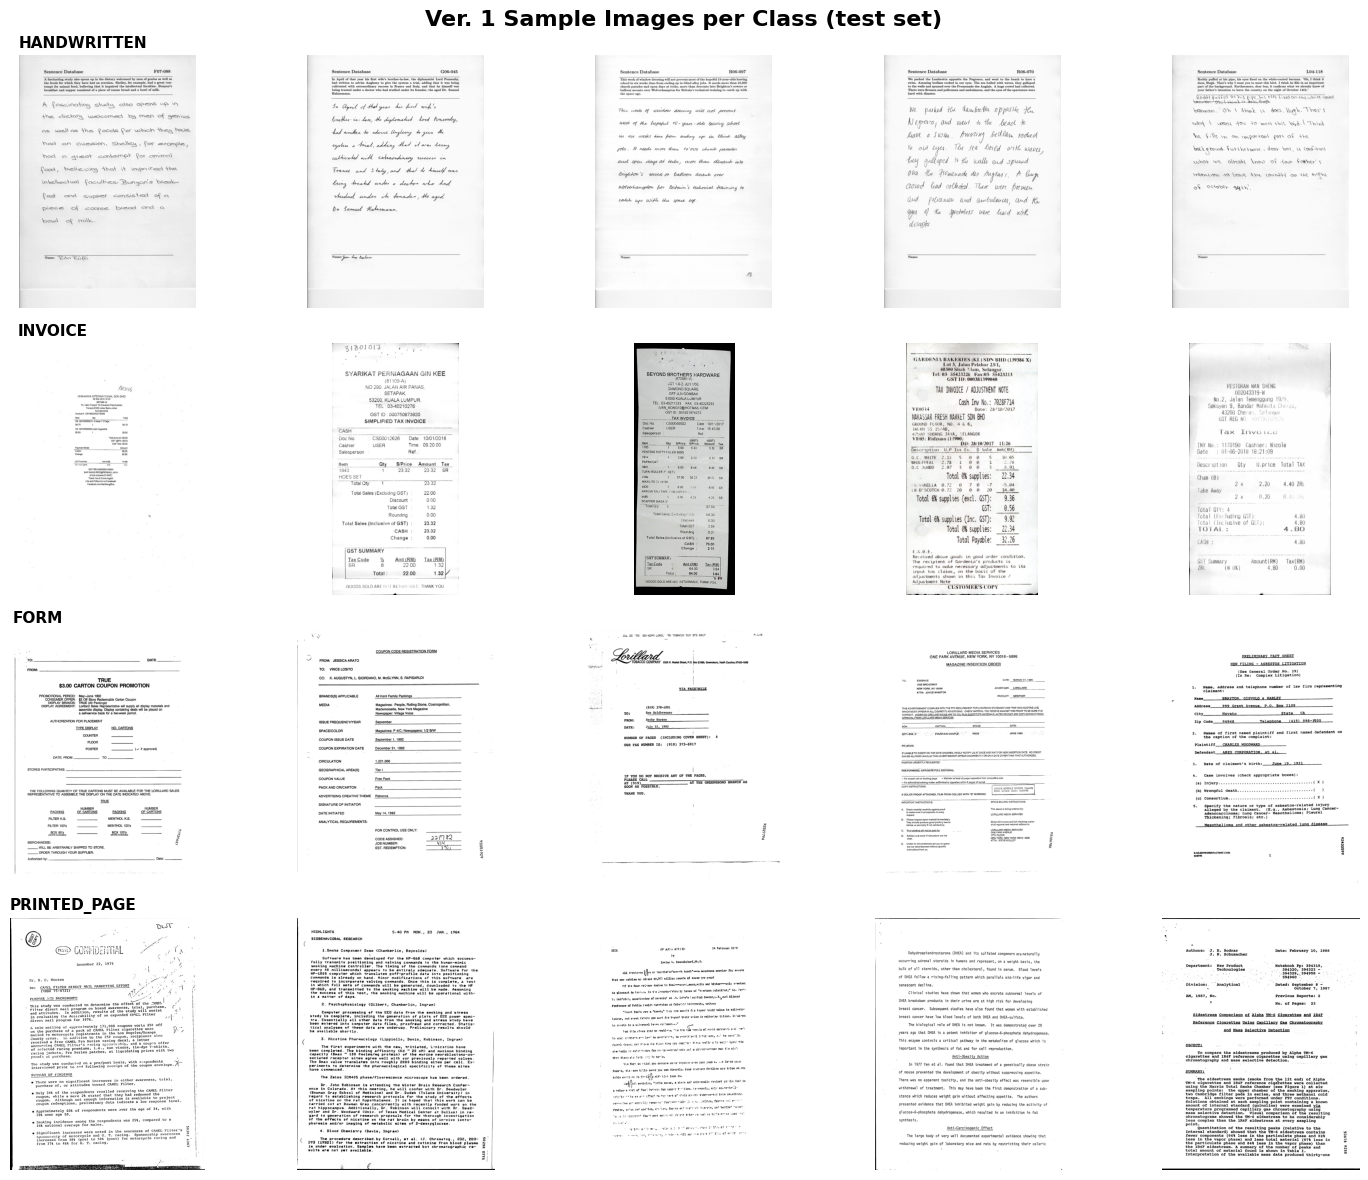

In [ ]:
#completely uneccesary, but it lets you see the type of documetns we used :)

#grid: one row per class, 5 sample images per row
fig, axes = plt.subplots(len(classes), 5, figsize=(15, 3 * len(classes)))
fig.suptitle('Ver. 1 Sample Images per Class (test set)', fontsize=16, fontweight='bold')

for row, (cls, idx) in enumerate(class_to_idx.items()):
    #get all test image paths that belong to this class
    cls_samples = [s[0] for s in test_dataset.samples if s[1] == idx]
    #5 random images from that class (or fewer if not enough exist)
    selected    = random.sample(cls_samples, min(5, len(cls_samples)))
    for col, img_path in enumerate(selected):
      #load and display the image in its grid cell
        axes[row][col].imshow(Image.open(img_path).convert('RGB'))
        #remove axis ticks and borders for a clean look
        axes[row][col].axis('off')
        #add the class name as a label on the leftmost image of each row
        if col == 0:
            axes[row][col].set_title(cls.upper(), fontsize=11,
                                     fontweight='bold', loc='left', pad=6)
plt.tight_layout()
#save for the report and Drive upload
plt.savefig('ver1_samples.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Save to Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

#make drive folder if it doesnt exist, then copy model and sample image
os.makedirs(drive_path, exist_ok=True)
shutil.copy(save_path,          f'{drive_path}/{save_path}')
shutil.copy('ver1_samples.png', f'{drive_path}/ver1_samples.png')

#plain text summary of the run, for the report and quick reference
summary = f"""
SmartScan, 4-Class Classifier (Ver. 1)
Model:         MobileNetV2 (frozen backbone, custom head)
Classes:       {classes}
Train images:  {len(train_dataset)}
Val images:    {len(val_dataset)}
Test images:   {len(test_dataset)
Test Accuracy:      {test_acc:.2f}%
Avg Confidence:     {avg_conf:.2f}%
Avg Latency/image:  {avg_latency:.2f} ms (CPU)
"""

with open(f'{drive_path}/summary_ver1.txt', 'w') as f:
    f.write(summary)

print(summary)
print("saved:", os.listdir(drive_path))

Mounted at /content/drive

SmartScan, 4-Class Classifier (Ver. 1)
Model:         MobileNetV2 (frozen backbone, custom head)
Classes:       ['handwritten', 'invoice', 'form', 'printed_page']
Train images:  2380
Val images:    297
Test images:   299

Test Accuracy:      98.33%
Avg Confidence:     93.94%
Avg Latency/image:  0.16 ms (CPU)

saved to: ['document_classifier.pt', 'training_summary.txt', 'sample_images.png', 'csci435.ipynb', 'ver1_samples.png', 'summary_part1.txt', 'classification_core.py', 'document_classifier_v2.pt', 'classification_extended.py', 'summary_part2.txt', 'part2_samples.png', 'document_classifier_bonus.pt', 'csci435_version2.ipynb', 'csci435_version1.ipynb', 'summary_ver1.txt']
